# Sistem Temu Kembali Informasi - Pencarian Lirik Lagu

```
Anggota Kelompok:
Elena Oktaviani ,2317051056
Sofia' Azahra ,2317051075
Amala Ratri Nugraheni ,2317051007
Raihan Andi Saungnaga ,2317051058
Achmad Ghalib Hafizh,2317051023
```

**Mata Kuliah**: Temu Kembali Informasi (STKI)

**Dataset**: Spotify 900K Songs (Kaggle)

**Model**: TF-IDF + Cosine Similarity




In [1]:
!pip install nltk wordcloud rank_bm25 -q

In [2]:
import pandas as pd
import numpy as np
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Load Dataset





**Tahap 1** (sekali jalan): Baca CSV → filter → sampling 50K → simpan ke Drive.

**Tahap 2** (setiap runtime baru): Langsung load file sampel dari Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/STKI'
CSV_FILE = f'{DRIVE_PATH}/spotify_dataset.csv'
SAMPLED_FILE = f'{DRIVE_PATH}/spotify_sampled_50k.csv'

Mounted at /content/drive


In [4]:
import psutil
from tqdm.notebook import tqdm

def get_ram_usage():
    mem = psutil.virtual_memory()
    return f'{mem.used / 1e9:.1f}GB / {mem.total / 1e9:.1f}GB ({mem.percent}%)'

if os.path.exists(SAMPLED_FILE):
    # --- TAHAP 2: file sampel sudah ada, langsung load ---
    df = pd.read_csv(SAMPLED_FILE)
    print(f'Loaded dari Drive: {len(df)} baris')
    print(f'RAM: {get_ram_usage()}')

else:
    # --- TAHAP 1: proses dari CSV mentah (hanya sekali) ---
    print(f'File sampel belum ada, memulai proses dari {CSV_FILE}')
    print(f'RAM awal: {get_ram_usage()}')

    # Hitung jumlah baris dulu untuk progress bar
    total_lines = sum(1 for _ in open(CSV_FILE, encoding='utf-8', errors='ignore')) - 1
    print(f'Total baris di CSV: {total_lines:,}')

    # Baca CSV per chunk agar RAM aman
    CHUNK_SIZE = 50_000
    filtered_chunks = []

    reader = pd.read_csv(CSV_FILE, chunksize=CHUNK_SIZE, low_memory=False)
    pbar = tqdm(total=total_lines, desc='Membaca CSV', unit='baris')

    for chunk in reader:
        # Deteksi & normalisasi nama kolom (hanya di chunk pertama yang masih pakai nama asli)
        col_map = {}
        for target, candidates in [
            ('judul', ['song', 'Track Name', 'title']),
            ('penyanyi', ['Artist(s)', 'Artist', 'artist']),
            ('lirik', ['text', 'lyrics', 'Lyrics']),
            ('genre', ['Genre', 'genre']),
        ]:
            for c in candidates:
                if c in chunk.columns:
                    col_map[c] = target
                    break
        chunk = chunk.rename(columns=col_map)

        # Hapus baris yang kosong
        required = [c for c in ['judul', 'penyanyi', 'lirik'] if c in chunk.columns]
        chunk = chunk.dropna(subset=required)

        # Filter lirik minimal 100 kata
        if 'lirik' in chunk.columns:
            chunk = chunk[chunk['lirik'].str.split().str.len() >= 100]

        # Ambil kolom yang dibutuhkan saja
        keep_cols = [c for c in ['judul', 'penyanyi', 'lirik', 'genre'] if c in chunk.columns]
        chunk = chunk[keep_cols]

        filtered_chunks.append(chunk)
        pbar.update(CHUNK_SIZE)

    pbar.close()

    # Gabung semua chunk
    df_full = pd.concat(filtered_chunks, ignore_index=True)
    del filtered_chunks
    print(f'Setelah filter: {len(df_full):,} lagu dengan lirik >= 100 kata')
    print(f'RAM setelah filter: {get_ram_usage()}')

    # Sampling 50.000 lagu
    n_sample = min(50_000, len(df_full))
    df = df_full.sample(n_sample, random_state=42).reset_index(drop=True)
    del df_full
    print(f'Sampel: {len(df):,} lagu')

    # Simpan ke Drive
    df.to_csv(SAMPLED_FILE, index=False)
    print(f'Tersimpan ke: {SAMPLED_FILE}')
    print(f'RAM akhir: {get_ram_usage()}')

print(f'\nDataset siap: {len(df)} baris x {len(df.columns)} kolom')

File sampel belum ada, memulai proses dari /content/drive/MyDrive/STKI/spotify_dataset.csv
RAM awal: 1.3GB / 13.6GB (12.4%)
Total baris di CSV: 551,443


Membaca CSV:   0%|          | 0/551443 [00:00<?, ?baris/s]

Setelah filter: 525,391 lagu dengan lirik >= 100 kata
RAM setelah filter: 3.0GB / 13.6GB (24.3%)
Sampel: 50,000 lagu
Tersimpan ke: /content/drive/MyDrive/STKI/spotify_sampled_50k.csv
RAM akhir: 2.9GB / 13.6GB (23.7%)

Dataset siap: 50000 baris x 4 kolom


In [5]:
print(f'Jumlah data: {len(df)}')
print(f'Kolom: {list(df.columns)}')
df.head()

Jumlah data: 50000
Kolom: ['judul', 'penyanyi', 'lirik', 'genre']


,judul,penyanyi,lirik,genre
0,Give Me Your Soul,King Diamond,"Give me your soul, give me your soul for the d...","heavy metal,metal"
1,LIGHTS OUT,Evilmane,I will catch you slippin' Lights out Stars go ...,hip hop
2,Imagination,Uriah Heep,Sometimes I'm certain Sometimes my mind is ...,"rock,progressive rock,heavy metal"
3,The Night Out,"Martin Solveig,A-Trak","[Verse 1] Hey baby, what's that sound? I make ...",hip hop
4,My Bike,Hori Shaw,[Frizzy Free] Yo Frizzy I'm on MY BIKE Ay yo D...,"jazz,swing"


## Preprocessing Teks

Tahapan preprocessing yang diterapkan:
1. **Case Folding** - mengubah ke huruf kecil
2. **Cleaning** - menghapus tag struktur lagu, URL, karakter spesial
3. **Tokenisasi** - memecah teks menjadi kata-kata
4. **Stopword Removal** - menghapus kata umum yang tidak informatif

In [6]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    if not isinstance(text, str):
        return ""

    # Case folding
    text = text.lower()

    # Hapus tag struktur lagu [Chorus], [Verse 1], (2x), dll
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)

    # Hapus karakter non-alfabet
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenisasi
    tokens = word_tokenize(text)

    # Stopword removal
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    return ' '.join(tokens)

In [7]:
df['processed'] = df['lirik'].apply(preprocess)

# Tampilkan contoh sebelum vs sesudah preprocessing
for i in range(3):
    print(f'=== Lagu: {df.iloc[i]["judul"]} ===')
    print(f'SEBELUM: {df.iloc[i]["lirik"][:200]}...')
    print(f'SESUDAH: {df.iloc[i]["processed"][:200]}...')
    print()

=== Lagu: Give Me Your Soul ===
SEBELUM: Give me your soul, give me your soul for the dead I think I know that little girl, I wonder where I've seen her before In a cellar down below, I see the little girl playing with a boy They're having f...
SESUDAH: give soul give soul dead think know little girl wonder ive seen cellar see little girl playing boy theyre fun comes daddy hes rage screaming yelling hes nice cold ice axe hand oh looks like hes going ...

=== Lagu: LIGHTS OUT ===
SEBELUM: I will catch you slippin' Lights out Stars go missin' Comin' at me sideways How we do it? My way I'm still livinn' with my pops The fuck u gonna say?   Rolinn' doja, left the homie with the motive On ...
SESUDAH: catch slippin lights stars go missin comin sideways way im still livinn pops fuck gon na say rolinn doja left homie motive corner came fron nothin smoking marijuana raw stoner serving plugs deal fiend...

=== Lagu: Imagination ===
SEBELUM: Sometimes I'm certain    Sometimes my mind is    Fille

## Indexing - TF-IDF Vectorization

Menggunakan TF-IDF (Term Frequency - Inverse Document Frequency) untuk mengubah teks lirik menjadi representasi vektor numerik yang bisa dihitung kemiripannya.

In [8]:
# Bangun TF-IDF matrix (sublinear_tf=True untuk scaling logaritmik pada term frequency)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['processed'])

print(f'TF-IDF Matrix: {tfidf_matrix.shape}')
print(f'  -> {tfidf_matrix.shape[0]} dokumen, {tfidf_matrix.shape[1]} fitur')

TF-IDF Matrix: (50000, 10000)
  -> 50000 dokumen, 10000 fitur


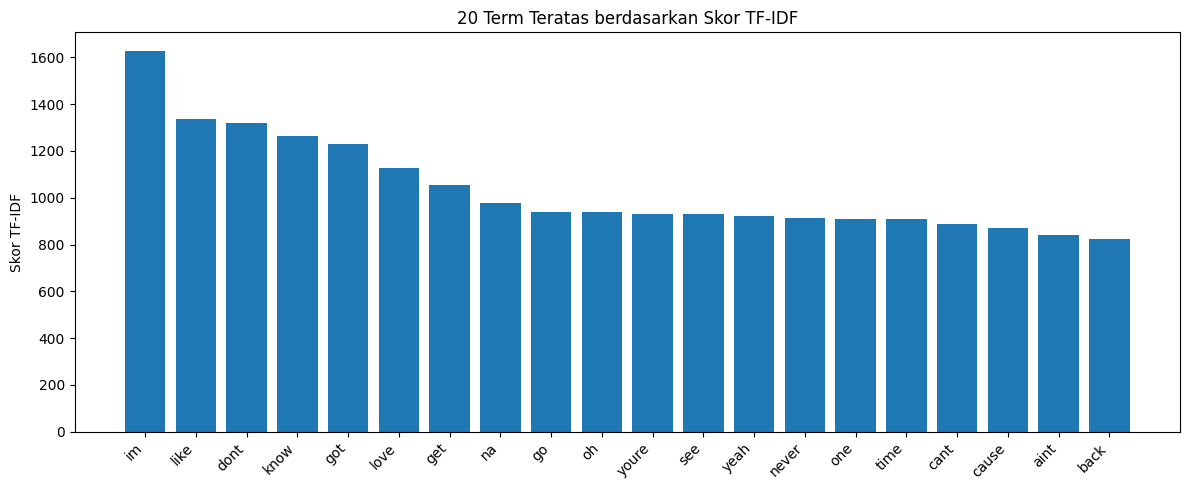

In [9]:
# 20 kata/frasa dengan skor TF-IDF tertinggi
feature_names = tfidf.get_feature_names_out()
tfidf_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()
top_idx = tfidf_scores.argsort()[-20:][::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(20), tfidf_scores[top_idx])
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('20 Term Teratas berdasarkan Skor TF-IDF')
plt.ylabel('Skor TF-IDF')
plt.tight_layout()
plt.show()

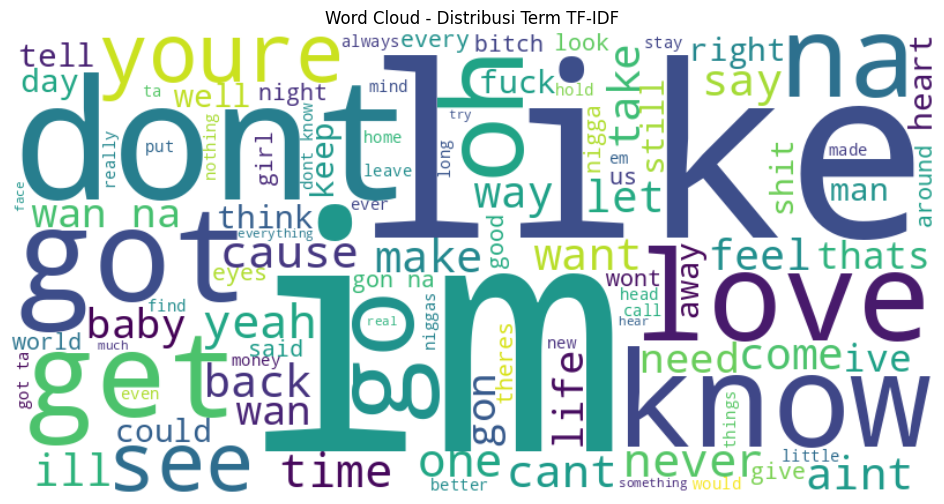

In [10]:
tfidf_dict = dict(zip(feature_names, tfidf_scores))
wc = WordCloud(width=800, height=400, background_color='white', max_words=100)
wc.generate_from_frequencies(tfidf_dict)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Distribusi Term TF-IDF')
plt.show()

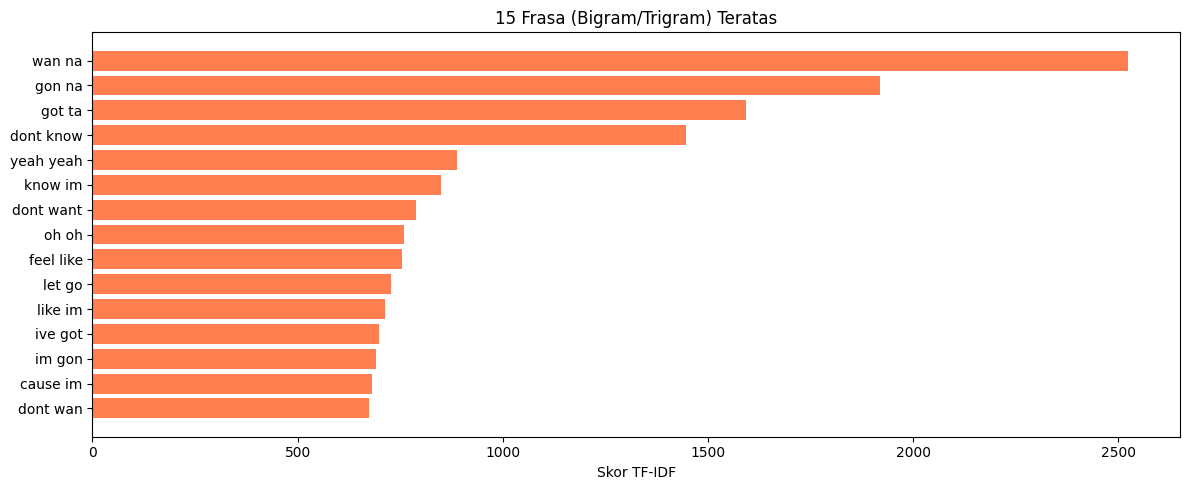

In [11]:
# Analisis Bigram & Trigram
tfidf_ngram = TfidfVectorizer(ngram_range=(2, 3), max_features=500)
ngram_matrix = tfidf_ngram.fit_transform(df['processed'])
ngram_names = tfidf_ngram.get_feature_names_out()
ngram_scores = np.array(ngram_matrix.sum(axis=0)).flatten()
top_ngram_idx = ngram_scores.argsort()[-15:][::-1]

plt.figure(figsize=(12, 5))
plt.barh(range(15), ngram_scores[top_ngram_idx][::-1], color='coral')
plt.yticks(range(15), [ngram_names[i] for i in top_ngram_idx][::-1])
plt.title('15 Frasa (Bigram/Trigram) Teratas')
plt.xlabel('Skor TF-IDF')
plt.tight_layout()
plt.show()

## Pencarian Dokumen (Information Retrieval)

Dua model pencarian yang digunakan:
1. **TF-IDF + Cosine Similarity** - model klasik berbasis vektor
2. **BM25 (Okapi BM25)** - model probabilistik yang menangani saturasi term frequency dan normalisasi panjang dokumen

In [12]:
from rank_bm25 import BM25Okapi

# Tokenisasi untuk BM25 (perlu list of list of tokens)
corpus_tokens = [doc.split() for doc in df['processed']]
bm25 = BM25Okapi(corpus_tokens)

print(f'BM25 index: {len(corpus_tokens)} dokumen')

BM25 index: 50000 dokumen


In [13]:
def search_tfidf(query, top_k=5):
    q_processed = preprocess(query)
    q_vector = tfidf.transform([q_processed])
    scores = cosine_similarity(q_vector, tfidf_matrix).flatten()
    top_indices = scores.argsort()[-top_k:][::-1]
    return [{'rank': r+1, 'idx': idx, 'judul': df.iloc[idx]['judul'],
             'penyanyi': df.iloc[idx]['penyanyi'], 'score': round(scores[idx], 4),
             'lirik_preview': df.iloc[idx]['lirik'][:150]} for r, idx in enumerate(top_indices)]

def search_bm25(query, top_k=5):
    q_tokens = preprocess(query).split()
    scores = bm25.get_scores(q_tokens)
    top_indices = scores.argsort()[-top_k:][::-1]
    return [{'rank': r+1, 'idx': idx, 'judul': df.iloc[idx]['judul'],
             'penyanyi': df.iloc[idx]['penyanyi'], 'score': round(scores[idx], 4),
             'lirik_preview': df.iloc[idx]['lirik'][:150]} for r, idx in enumerate(top_indices)]

In [14]:
demo_queries = [
    "love me tonight under the stars",
    "broken heart crying alone",
    "dance party friday night"
]

for q in demo_queries:
    print(f'Query: "{q}"')
    print(f'Preprocessed: "{preprocess(q)}"')
    print('-' * 70)
    print('  TF-IDF:')
    for r in search_tfidf(q, top_k=3):
        print(f'    #{r["rank"]} {r["judul"]} - {r["penyanyi"]} ({r["score"]})')
    print('  BM25:')
    for r in search_bm25(q, top_k=3):
        print(f'    #{r["rank"]} {r["judul"]} - {r["penyanyi"]} ({r["score"]})')
    print()

Query: "love me tonight under the stars"
Preprocessed: "love tonight stars"
----------------------------------------------------------------------
  TF-IDF:
    #1 Heal Me - Flowidus,Matisse (0.4232)
    #2 Your Love (L.o.v.e. Reggae Mix) - Wyclef Jean,Claudette Ortiz (0.3912)
    #3 Your Love (L.o.v.e. Reggae Mix) - Wyclef Jean,Claudette Ortiz (0.3912)
  BM25:
    #1 A thousand stars - Eugene Pearson,Billy Fury (12.7472)
    #2 Parallel - Heffron Drive (12.742)
    #3 Stars - Outsiders,Charly Lownoise,Starsplash (12.5927)

Query: "broken heart crying alone"
Preprocessed: "broken heart crying alone"
----------------------------------------------------------------------
  TF-IDF:
    #1 A Broken Heart Can Mend - Alexander O'Neal (0.4239)
    #2 Broken Heart - The Contessas (0.3744)
    #3 Born With a Broken Heart - Primal Fear (0.3584)
  BM25:
    #1 Upset Stomach - Stevie Wonder (19.3186)
    #2 Can't Get Enough - Modern Talking (16.5312)
    #3 Think Of You All Of The Time - Keith Mar

## Evaluasi Performa Sistem

Menggunakan **10 query pengujian** dengan ground truth untuk membandingkan **TF-IDF vs BM25**.

Metrik yang dihitung:
- **Precision@1** - apakah hasil pertama benar
- **Precision@3** - berapa persen dari top 3 yang benar
- **Recall@3** - apakah lagu yang dicari ditemukan di top 3
- **MAP (Mean Average Precision)** - rata-rata akurasi keseluruhan

In [15]:
gt_songs = df.sample(10, random_state=99).reset_index(drop=True)

test_queries = []
for _, row in gt_songs.iterrows():
    words = row['lirik'].split()
    start = len(words) // 3
    snippet = ' '.join(words[start:start + 20])
    test_queries.append({'query': snippet, 'ground_truth': row['judul']})

gt_df = pd.DataFrame(test_queries)
gt_df.index = gt_df.index + 1
gt_df

,query,ground_truth
1,wrong and make it right All I need is a touch ...,All I Need
2,"little girl, come on and dance with me You're ...",Hey Little Girl
3,where he played as a boy He knew he had to fin...,Simple Joys
4,the rockets Pull the stops out [ALL] Pull out ...,Its Today
5,American rock 'n roll [Verse 2] I can see the ...,American Rock n Roll
6,by my sin Had no ears to hear Your voice Did n...,O Great God
7,"derri? Re eux amour, espoirs Comme lumi? Re po...",L'Univers A Besoin D'Amour
8,forever To put you back together [Post-Chorus]...,BLACK SOUL
9,"all I see is life, life in a beautiful light A...",Life in a Beautiful Light
10,Just say the word and I'll listen Don't ever b...,Reassurance


In [16]:
def evaluate_model(search_fn, test_queries):
    eval_rows = []
    total_ap = 0.0

    for i, tq in enumerate(test_queries):
        results = search_fn(tq['query'], top_k=3)
        retrieved_titles = [r['judul'].lower().strip() for r in results]
        gt = tq['ground_truth'].lower().strip()

        p1 = 1 if retrieved_titles and gt == retrieved_titles[0] else 0
        relevant = sum(1 for t in retrieved_titles if gt == t)
        p3 = relevant / 3.0
        r3 = 1 if gt in retrieved_titles else 0

        ap = 0.0
        for rank, t in enumerate(retrieved_titles):
            if gt == t:
                ap = 1.0 / (rank + 1)
                break
        total_ap += ap

        retrieved_str = ' | '.join([f'#{r["rank"]} {r["judul"]} ({r["score"]})' for r in results])
        eval_rows.append({
            'No': i + 1,
            'Query': tq['query'][:60] + '...',
            'Ground Truth': tq['ground_truth'],
            'Hasil Retrieval': retrieved_str,
            'P@1': p1, 'P@3': round(p3, 2), 'Recall@3': r3, 'AP': round(ap, 2)
        })

    map_score = total_ap / len(test_queries)
    return eval_rows, map_score

In [17]:
tfidf_eval, tfidf_map = evaluate_model(search_tfidf, test_queries)
print('=== Evaluasi TF-IDF ===')
print(f'MAP: {tfidf_map:.2%}')
print(f'Avg P@1: {np.mean([r["P@1"] for r in tfidf_eval]):.2%}')
print(f'Avg Recall@3: {np.mean([r["Recall@3"] for r in tfidf_eval]):.2%}')
print()
pd.DataFrame(tfidf_eval)

=== Evaluasi TF-IDF ===
MAP: 95.00%
Avg P@1: 90.00%
Avg Recall@3: 100.00%



,No,Query,Ground Truth,Hasil Retrieval,P@1,P@3,Recall@3,AP
0,1,wrong and make it right All I need is a touch ...,All I Need,#1 All I Need (0.4659) | #2 Desired Constellat...,1,0.33,1,1.0
1,2,"little girl, come on and dance with me You're ...",Hey Little Girl,#1 Hey Little Girl (0.6517) | #2 Lookout (0.37...,1,0.33,1,1.0
2,3,where he played as a boy He knew he had to fin...,Simple Joys,#1 Simple Joys (0.2966) | #2 Same Love (0.2153...,1,0.33,1,1.0
3,4,the rockets Pull the stops out [ALL] Pull out ...,Its Today,#1 Its Today (0.4056) | #2 Theres A Lull In My...,1,0.33,1,1.0
4,5,American rock 'n roll [Verse 2] I can see the ...,American Rock n Roll,#1 Do You Like Worms? Smile Sessions Version (...,0,0.33,1,0.5
5,6,by my sin Had no ears to hear Your voice Did n...,O Great God,#1 O Great God (0.3871) | #2 Living Inside The...,1,0.33,1,1.0
6,7,"derri? Re eux amour, espoirs Comme lumi? Re po...",L'Univers A Besoin D'Amour,#1 L'Univers A Besoin D'Amour (0.5517) | #2 Pe...,1,0.33,1,1.0
7,8,forever To put you back together [Post-Chorus]...,BLACK SOUL,#1 BLACK SOUL (0.4979) | #2 Show Me (0.3306) |...,1,0.33,1,1.0
8,9,"all I see is life, life in a beautiful light A...",Life in a Beautiful Light,#1 Life in a Beautiful Light (0.5526) | #2 All...,1,0.33,1,1.0
9,10,Just say the word and I'll listen Don't ever b...,Reassurance,#1 Reassurance (0.4904) | #2 Fuck with Myself ...,1,0.33,1,1.0


In [18]:
bm25_eval, bm25_map = evaluate_model(search_bm25, test_queries)
print('=== Evaluasi BM25 ===')
print(f'MAP: {bm25_map:.2%}')
print(f'Avg P@1: {np.mean([r["P@1"] for r in bm25_eval]):.2%}')
print(f'Avg Recall@3: {np.mean([r["Recall@3"] for r in bm25_eval]):.2%}')
print()
pd.DataFrame(bm25_eval)

=== Evaluasi BM25 ===
MAP: 100.00%
Avg P@1: 100.00%
Avg Recall@3: 100.00%



,No,Query,Ground Truth,Hasil Retrieval,P@1,P@3,Recall@3,AP
0,1,wrong and make it right All I need is a touch ...,All I Need,#1 All I Need (24.2512) | #2 I Have A Crush On...,1,0.33,1,1.0
1,2,"little girl, come on and dance with me You're ...",Hey Little Girl,#1 Hey Little Girl (43.7406) | #2 Old Terror (...,1,0.33,1,1.0
2,3,where he played as a boy He knew he had to fin...,Simple Joys,#1 Simple Joys (51.2661) | #2 Sandpaper Kisses...,1,0.33,1,1.0
3,4,the rockets Pull the stops out [ALL] Pull out ...,Its Today,#1 Its Today (71.0522) | #2 Live / Breathe (28...,1,0.33,1,1.0
4,5,American rock 'n roll [Verse 2] I can see the ...,American Rock n Roll,#1 American Rock n Roll (56.8028) | #2 America...,1,0.33,1,1.0
5,6,by my sin Had no ears to hear Your voice Did n...,O Great God,#1 O Great God (34.1869) | #2 Living Inside Th...,1,0.33,1,1.0
6,7,"derri? Re eux amour, espoirs Comme lumi? Re po...",L'Univers A Besoin D'Amour,#1 L'Univers A Besoin D'Amour (205.3287) | #2 ...,1,0.33,1,1.0
7,8,forever To put you back together [Post-Chorus]...,BLACK SOUL,#1 BLACK SOUL (44.3157) | #2 Mrs. Potato Head ...,1,0.33,1,1.0
8,9,"all I see is life, life in a beautiful light A...",Life in a Beautiful Light,#1 Life in a Beautiful Light (29.9865) | #2 Be...,1,0.33,1,1.0
9,10,Just say the word and I'll listen Don't ever b...,Reassurance,#1 Reassurance (33.109) | #2 You Wont Get with...,1,0.33,1,1.0


## Perbandingan Model: TF-IDF vs BM25

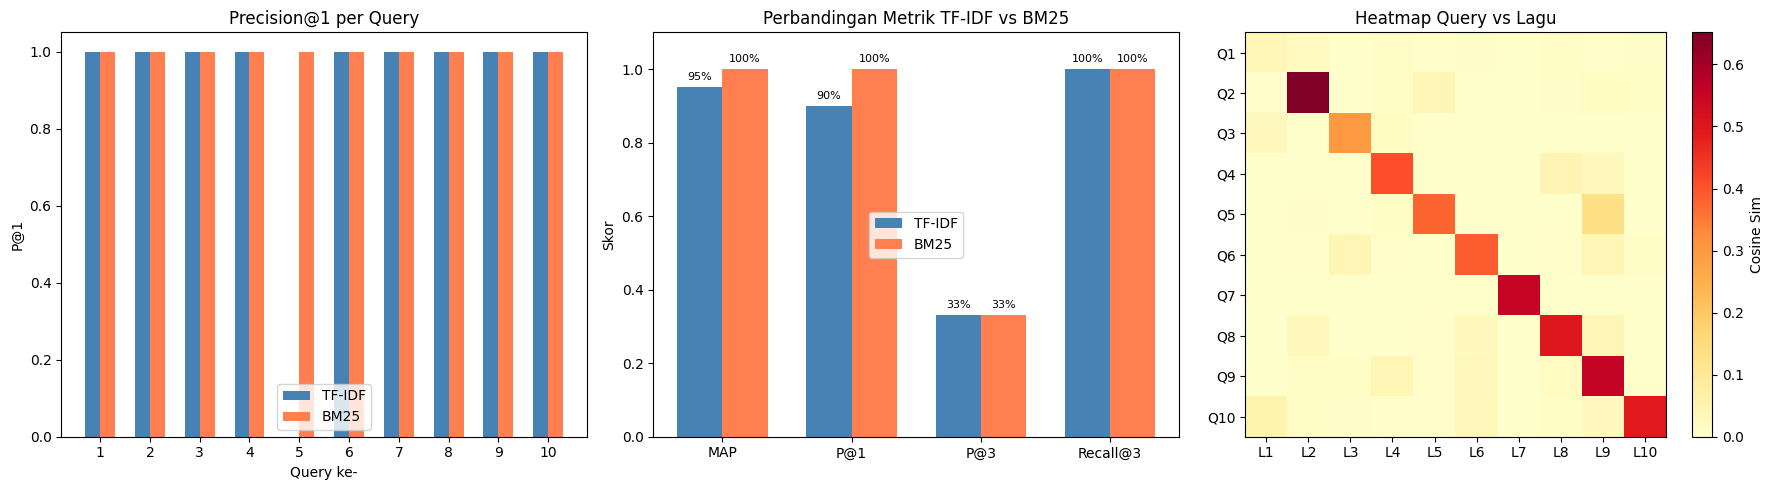


Model             MAP      P@1      P@3   Recall@3
TF-IDF         95.0%   90.0%   33.0%    100.0%
BM25          100.0%  100.0%   33.0%    100.0%
Model terbaik: BM25


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Perbandingan P@1 per query
x = range(len(test_queries))
axes[0].bar([i - 0.15 for i in x], [r['P@1'] for r in tfidf_eval], width=0.3, label='TF-IDF', color='steelblue')
axes[0].bar([i + 0.15 for i in x], [r['P@1'] for r in bm25_eval], width=0.3, label='BM25', color='coral')
axes[0].set_xlabel('Query ke-')
axes[0].set_ylabel('P@1')
axes[0].set_title('Precision@1 per Query')
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(i+1) for i in x])
axes[0].legend()

# 2. Perbandingan metrik keseluruhan
labels = ['MAP', 'P@1', 'P@3', 'Recall@3']
tfidf_vals = [tfidf_map, np.mean([r['P@1'] for r in tfidf_eval]),
              np.mean([r['P@3'] for r in tfidf_eval]), np.mean([r['Recall@3'] for r in tfidf_eval])]
bm25_vals = [bm25_map, np.mean([r['P@1'] for r in bm25_eval]),
             np.mean([r['P@3'] for r in bm25_eval]), np.mean([r['Recall@3'] for r in bm25_eval])]

bar_w = 0.35
axes[1].bar([i - bar_w/2 for i in range(len(labels))], tfidf_vals, bar_w, label='TF-IDF', color='steelblue')
axes[1].bar([i + bar_w/2 for i in range(len(labels))], bm25_vals, bar_w, label='BM25', color='coral')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Skor')
axes[1].set_title('Perbandingan Metrik TF-IDF vs BM25')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, (tv, bv) in enumerate(zip(tfidf_vals, bm25_vals)):
    axes[1].text(i - bar_w/2, tv + 0.02, f'{tv:.0%}', ha='center', fontsize=8)
    axes[1].text(i + bar_w/2, bv + 0.02, f'{bv:.0%}', ha='center', fontsize=8)

# 3. Heatmap similarity
sim_matrix = np.zeros((len(test_queries), len(test_queries)))
for i, tq in enumerate(test_queries):
    q_vec = tfidf.transform([preprocess(tq['query'])])
    for j, tq2 in enumerate(test_queries):
        gt_idx = df[df['judul'] == tq2['ground_truth']].index
        if len(gt_idx) > 0:
            sim_matrix[i][j] = cosine_similarity(q_vec, tfidf_matrix[gt_idx[0]]).flatten()[0]

im = axes[2].imshow(sim_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[2], label='Cosine Sim')
axes[2].set_xticks(range(len(test_queries)))
axes[2].set_xticklabels([f'L{i+1}' for i in range(len(test_queries))])
axes[2].set_yticks(range(len(test_queries)))
axes[2].set_yticklabels([f'Q{i+1}' for i in range(len(test_queries))])
axes[2].set_title('Heatmap Query vs Lagu')

plt.tight_layout()
plt.show()

# Ringkasan
print(f'\n{"="*50}')
print(f'{"Model":<12} {"MAP":>8} {"P@1":>8} {"P@3":>8} {"Recall@3":>10}')
print(f'{"="*50}')
print(f'{"TF-IDF":<12} {tfidf_map:>7.1%} {tfidf_vals[1]:>7.1%} {tfidf_vals[2]:>7.1%} {tfidf_vals[3]:>9.1%}')
print(f'{"BM25":<12} {bm25_map:>7.1%} {bm25_vals[1]:>7.1%} {bm25_vals[2]:>7.1%} {bm25_vals[3]:>9.1%}')
print(f'{"="*50}')
best = 'BM25' if bm25_map > tfidf_map else 'TF-IDF'
print(f'Model terbaik: {best}')

## Pencarian Interaktif

Cell di bawah ini bisa digunakan untuk mencoba pencarian secara manual.

In [23]:
query_input = input('Masukkan query pencarian: ')
if query_input:
    print(f'\nQuery: "{query_input}"')
    print(f'Preprocessed: "{preprocess(query_input)}"')
    print('=' * 70)
    print('\n--- TF-IDF ---')
    for r in search_tfidf(query_input, top_k=5):
        print(f'  #{r["rank"]} {r["judul"]} - {r["penyanyi"]} (score: {r["score"]})')
    print('\n--- BM25 ---')
    for r in search_bm25(query_input, top_k=5):
        print(f'  #{r["rank"]} {r["judul"]} - {r["penyanyi"]} (score: {r["score"]})')

Masukkan query pencarian: darling hold my hand

Query: "darling hold my hand"
Preprocessed: "darling hold hand"

--- TF-IDF ---
  #1 Tribe - Lost Tribe Aotearoa (score: 0.4755)
  #2 I Wanna Hold Your Hand - Big Time Rush (score: 0.3868)
  #3 I Want to Hold Your Hand - The Beatles (score: 0.3792)
  #4 Midnight Sky - Unique Salonga (score: 0.3753)
  #5 Faith - Hakeem Prime (score: 0.3632)

--- BM25 ---
  #1 Hold My Hand - Megan Davies (score: 16.6695)
  #2 I Beg Of You - Allman Brothers Band (score: 15.8595)
  #3 Baby I Want You - Amos Lee (score: 15.2607)
  #4 Do Better - Cuco (score: 15.2442)
  #5 Superman - Scouting For Girls (score: 14.8523)
